<a href="https://colab.research.google.com/github/gabriduarte2000-glitch/Trabalho-3-Processamento-de-Sinais/blob/main/Pratica3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

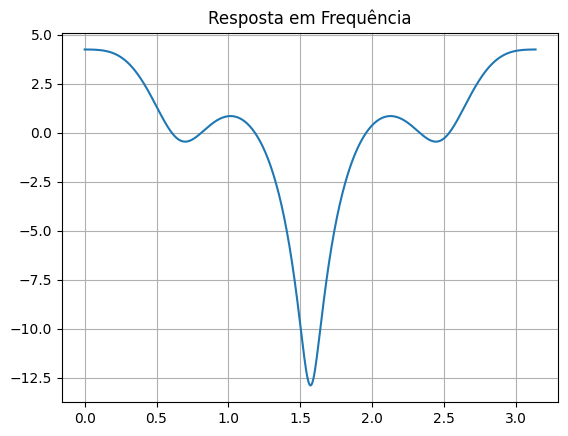

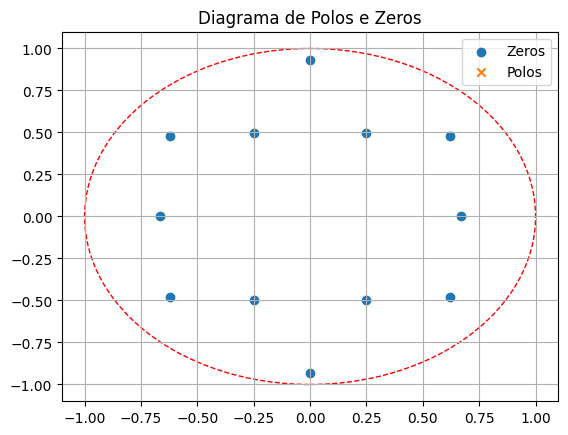

In [ ]:
# Questão 1
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

b1 = [1, 0, -0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138] # Ajustando conforme a expressão
b1 = [1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138]
a1 = [1]

w, h = signal.freqz(b1, a1)
plt.figure()
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Resposta em Frequência')
plt.grid()
plt.show()

z, p, k = signal.tf2zpk(b1, a1)
plt.figure()
plt.scatter(np.real(z), np.imag(z), marker='o', label='Zeros')
plt.scatter(np.real(p), np.imag(p), marker='x', label='Polos')
plt.axac = plt.gca()
plt.axac.add_patch(plt.Circle((0,0), 1, color='r', fill=False, linestyle='--'))
plt.title('Diagrama de Polos e Zeros')
plt.grid()
plt.legend()
plt.show()

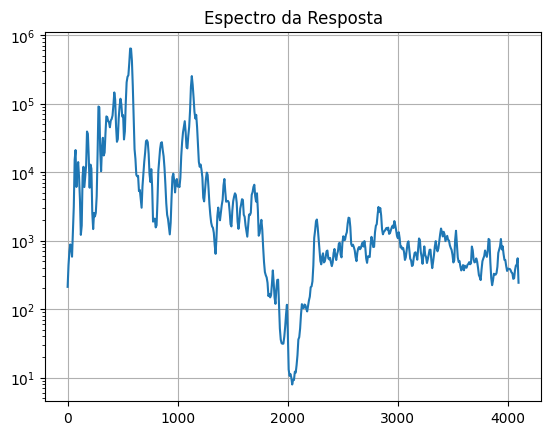

In [ ]:
# Questão 2
fs, x = wav.read('handel.wav')
if x.ndim > 1:
    x = x[:, 0]
x = x.astype(float)

y = signal.lfilter(b1, a1, x)

f, Pxx = signal.welch(y, fs, nperseg=1024)
plt.figure()
plt.semilogy(f, Pxx)
plt.title('Espectro da Resposta')
plt.grid()
plt.show()

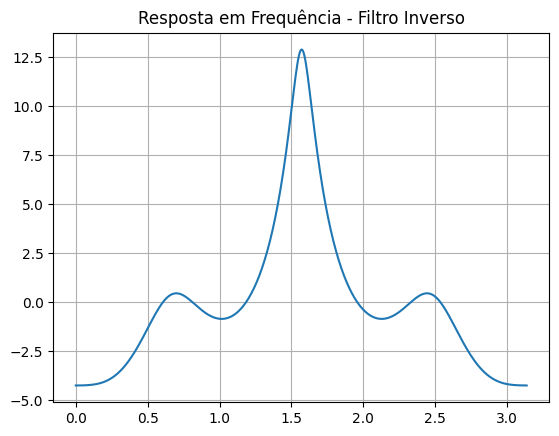

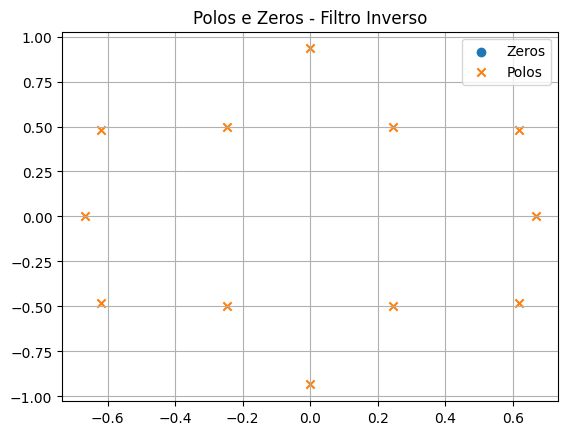

Erro médio quadrático: 1.8836484677266728e-25


In [ ]:
# Questão 3
b_inv = a1
a_inv = b1

w_inv, h_inv = signal.freqz(b_inv, a_inv)
plt.figure()
plt.plot(w_inv, 20 * np.log10(abs(h_inv)))
plt.title('Resposta em Frequência - Filtro Inverso')
plt.grid()
plt.show()

z_inv, p_inv, k_inv = signal.tf2zpk(b_inv, a_inv)
plt.figure()
plt.scatter(np.real(z_inv), np.imag(z_inv), marker='o', label='Zeros')
plt.scatter(np.real(p_inv), np.imag(p_inv), marker='x', label='Polos')
plt.title('Polos e Zeros - Filtro Inverso')
plt.grid()
plt.legend()
plt.show()

x_rec = signal.lfilter(b_inv, a_inv, y)
erro = np.mean((x[:len(x_rec)] - x_rec) ** 2)
print(f'Erro médio quadrático: {erro}')

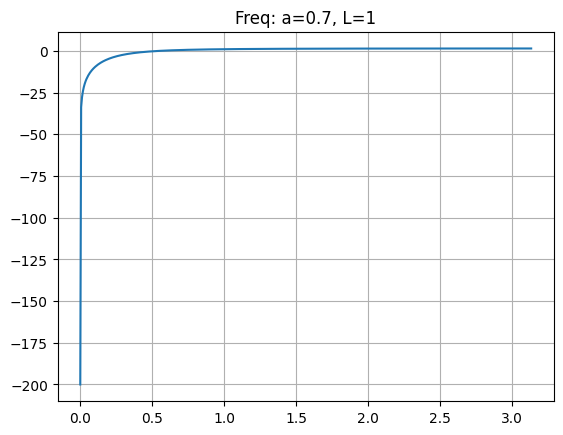

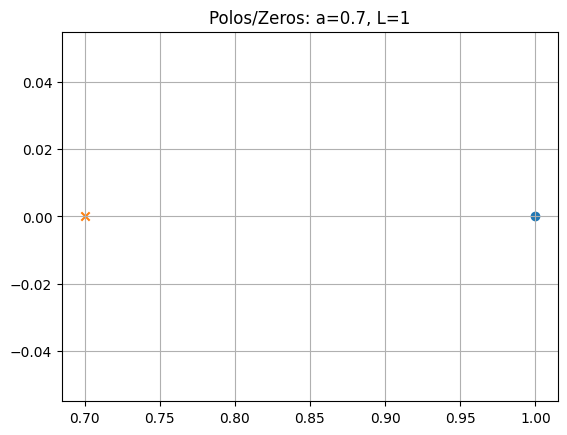

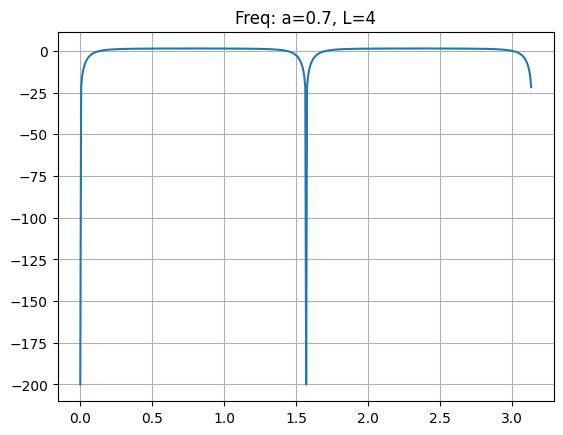

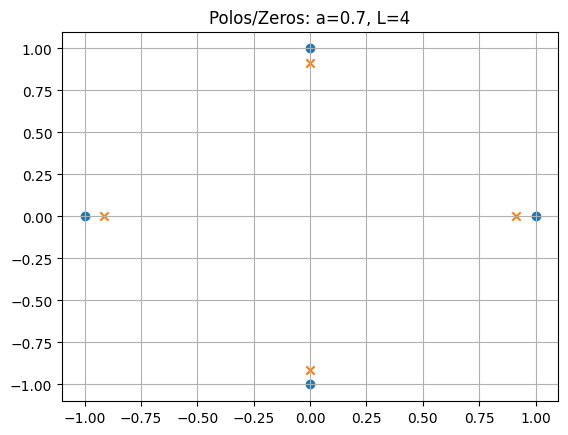

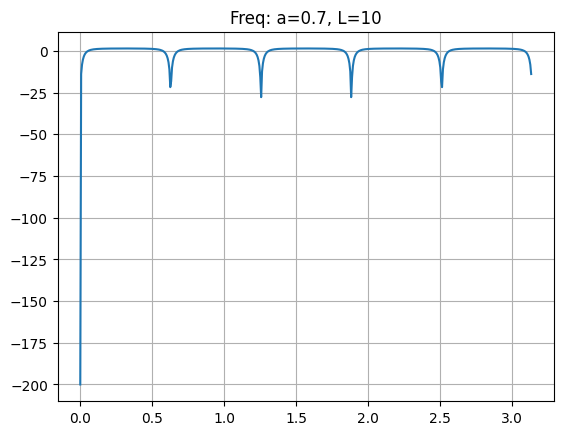

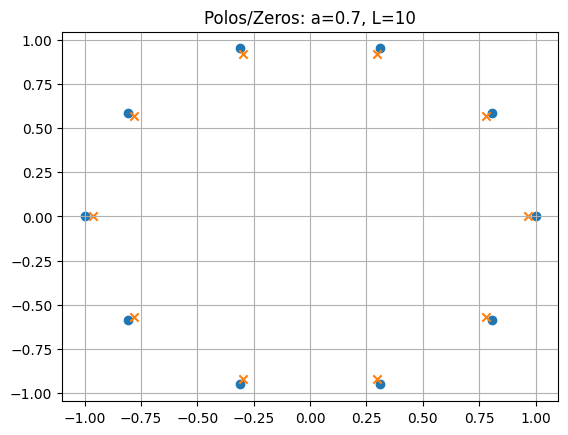

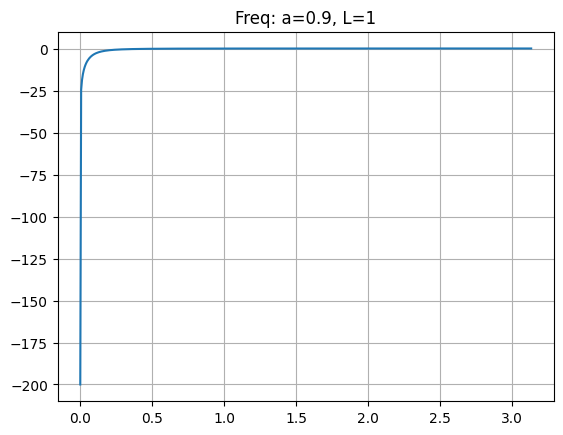

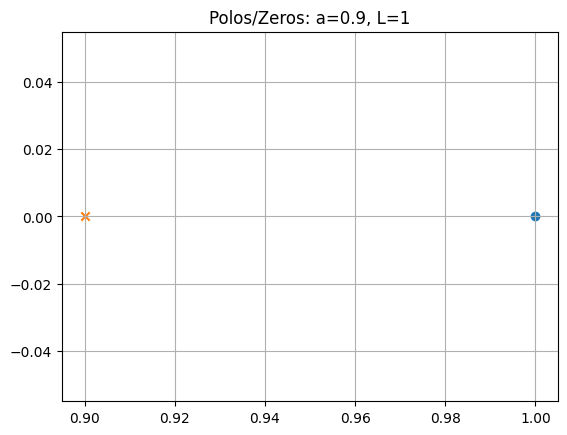

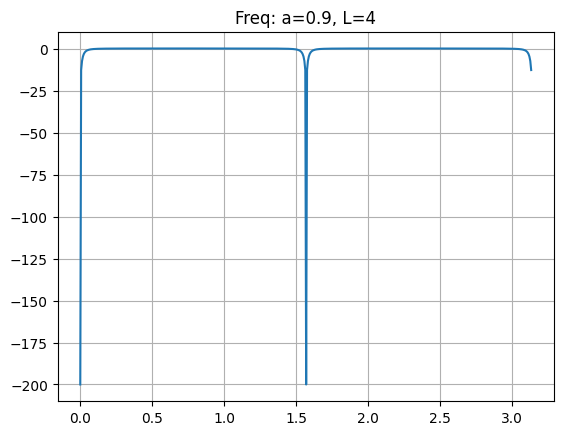

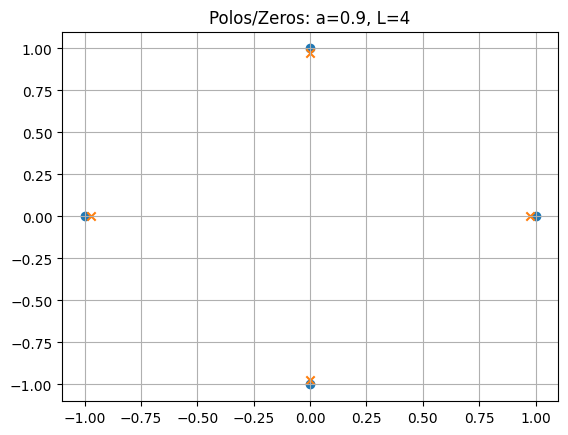

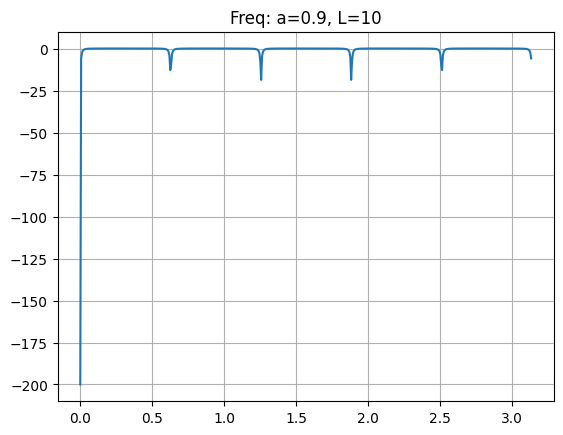

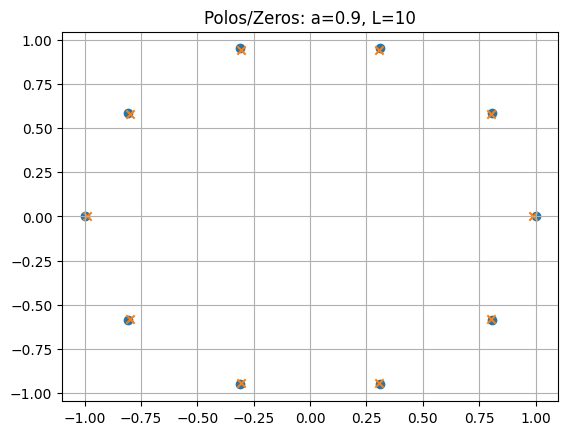

In [ ]:
# Questão 4
a_vals = [0.7, 0.9]
L_vals = [1, 4, 10]

for a in a_vals:
    for L in L_vals:
        b = np.zeros(L + 1)
        b[0] = 1
        b[L] = -1

        ac = np.zeros(L + 1)
        ac[0] = 1
        ac[L] = -a

        w, h = signal.freqz(b, ac)
        plt.figure()
        plt.plot(w, 20 * np.log10(abs(h) + 1e-10))
        plt.title(f'Freq: a={a}, L={L}')
        plt.grid()
        plt.show()

        z, p, k = signal.tf2zpk(b, ac)
        plt.figure()
        plt.scatter(np.real(z), np.imag(z), marker='o')
        plt.scatter(np.real(p), np.imag(p), marker='x')
        plt.title(f'Polos/Zeros: a={a}, L={L}')
        plt.grid()
        plt.show()

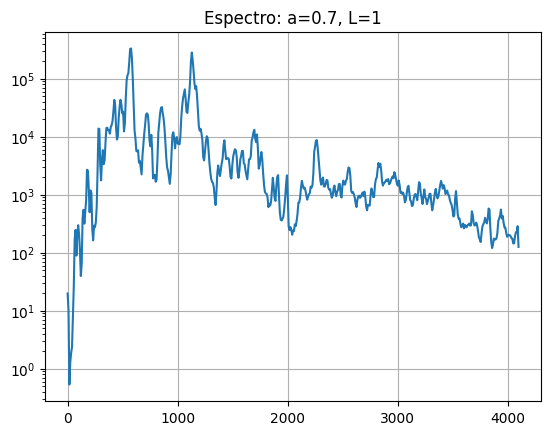

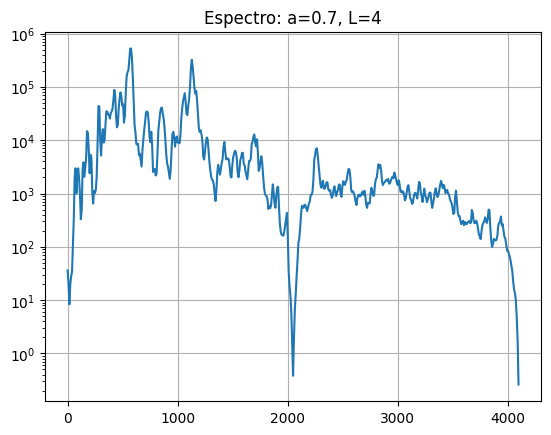

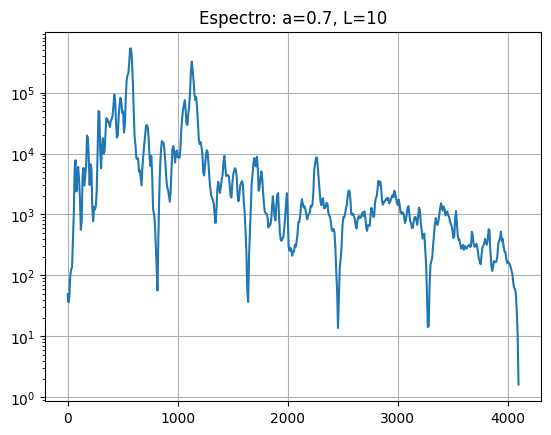

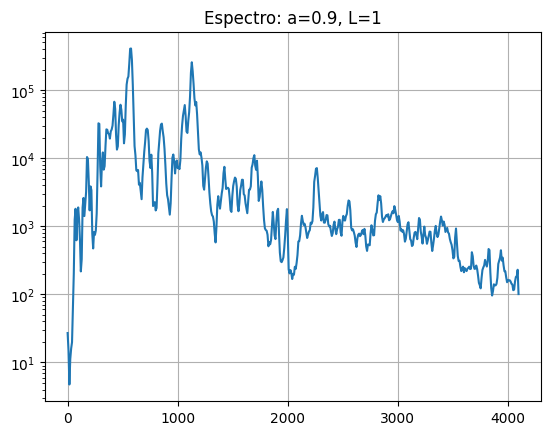

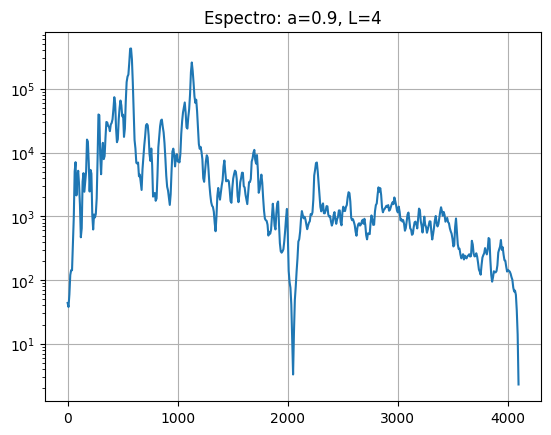

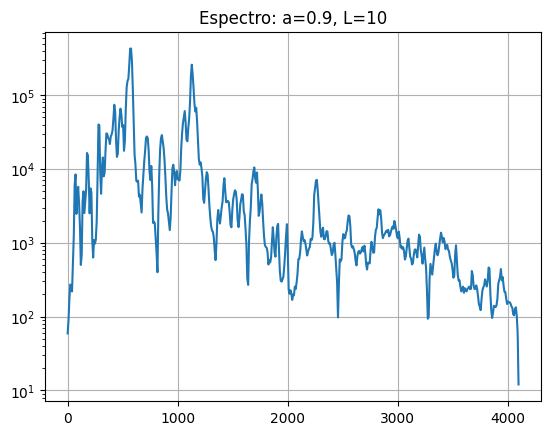

In [ ]:
# Questão 5
for a in a_vals:
    for L in L_vals:
        b = np.zeros(L + 1)
        b[0] = 1
        b[L] = -1

        ac = np.zeros(L + 1)
        ac[0] = 1
        ac[L] = -a

        y_q5 = signal.lfilter(b, ac, x)
        f, Pxx = signal.welch(y_q5, fs, nperseg=1024)
        plt.figure()
        plt.semilogy(f, Pxx)
        plt.title(f'Espectro: a={a}, L={L}')
        plt.grid()
        plt.show()

/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


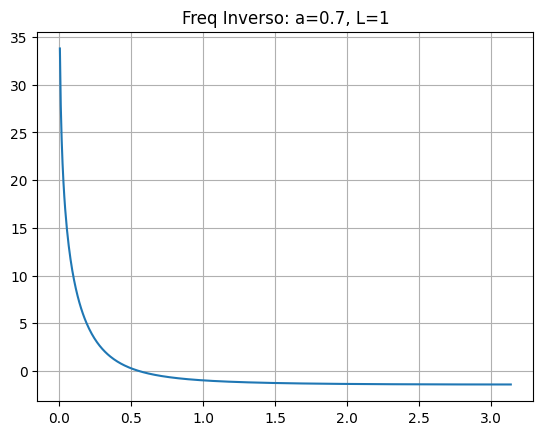

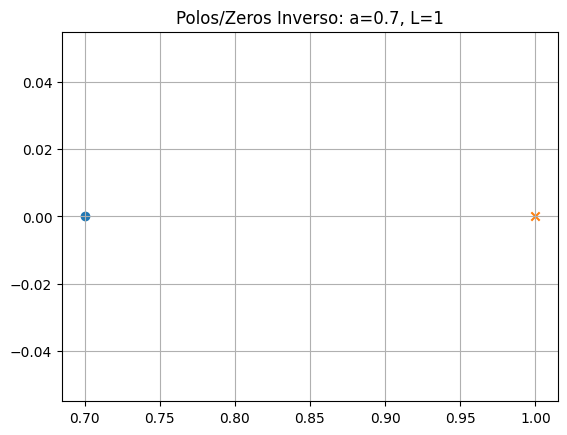

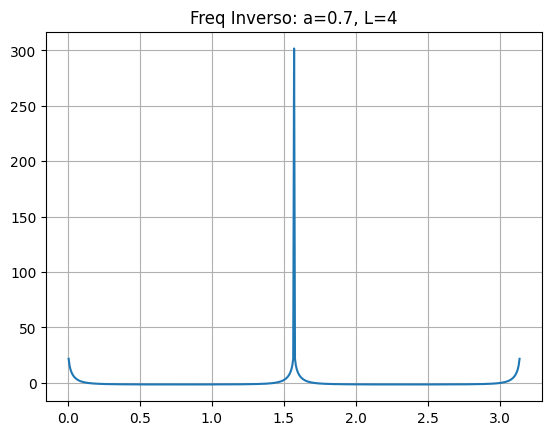

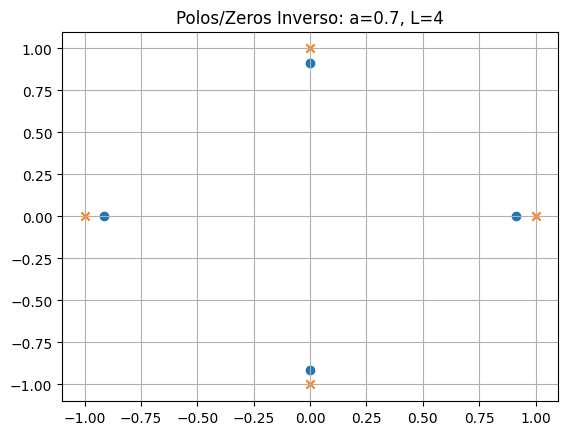

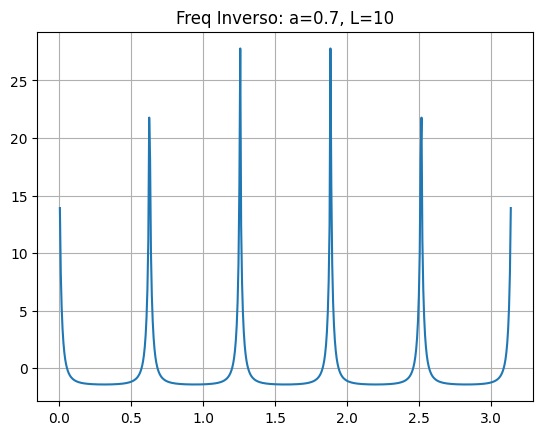

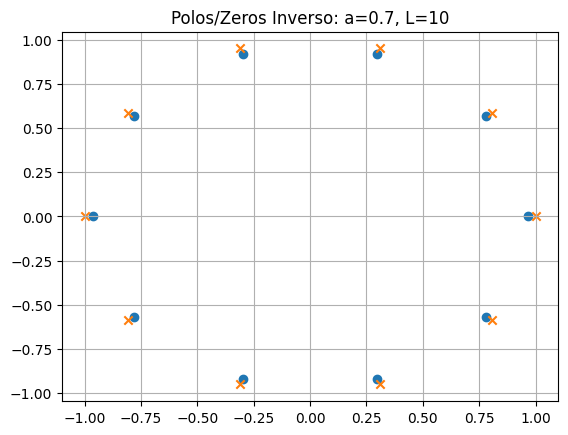

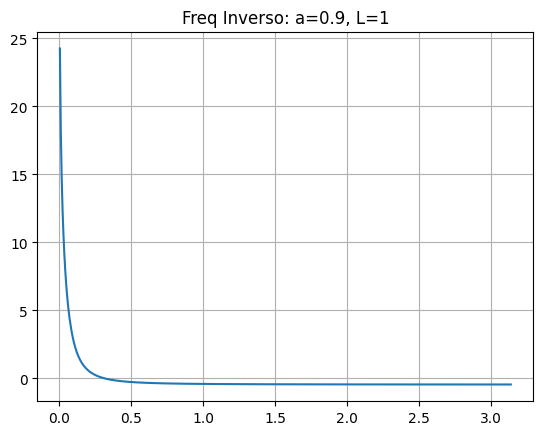

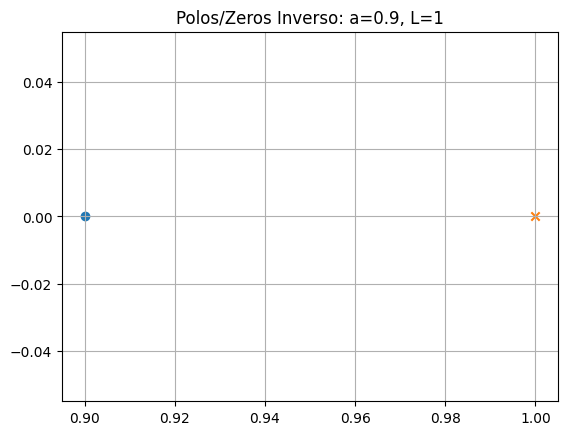

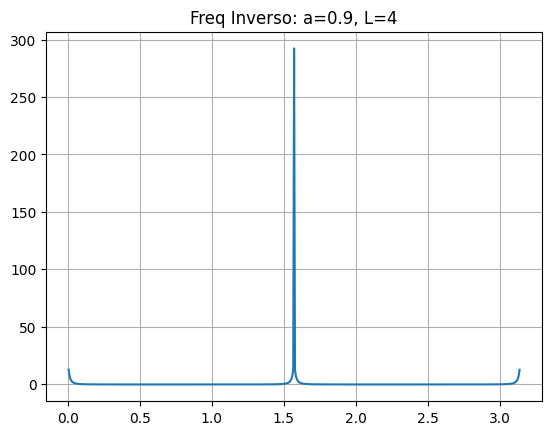

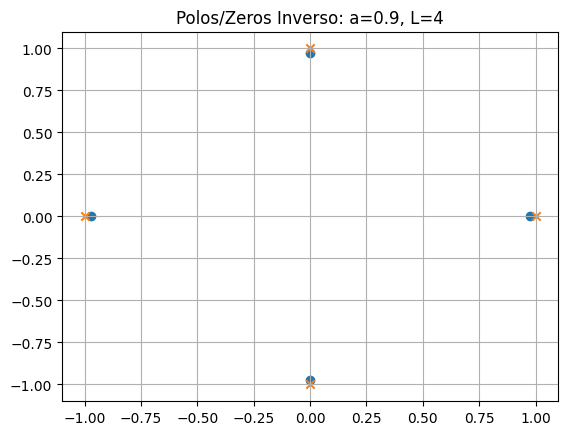

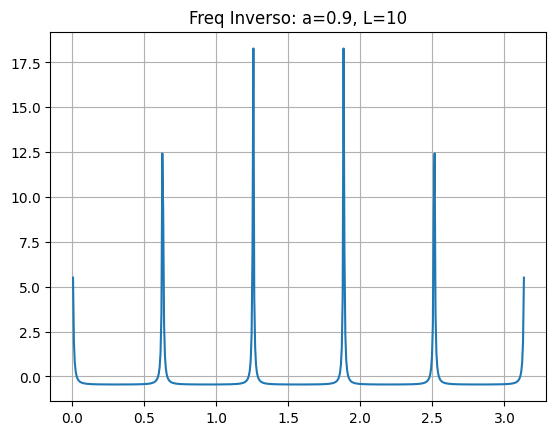

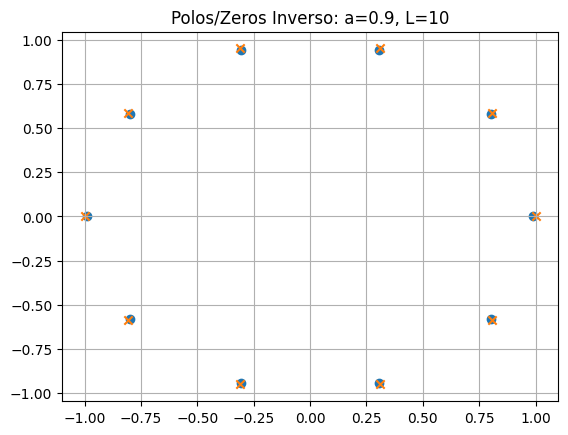

In [ ]:
# Questão 6
for a in a_vals:
    for L in L_vals:
        b_inv = np.zeros(L + 1)
        b_inv[0] = 1
        b_inv[L] = -a

        a_inv = np.zeros(L + 1)
        a_inv[0] = 1
        a_inv[L] = -1

        w, h = signal.freqz(b_inv, a_inv)
        plt.figure()
        plt.plot(w, 20 * np.log10(abs(h) + 1e-10))
        plt.title(f'Freq Inverso: a={a}, L={L}')
        plt.grid()
        plt.show()

        z, p, k = signal.tf2zpk(b_inv, a_inv)
        plt.figure()
        plt.scatter(np.real(z), np.imag(z), marker='o')
        plt.scatter(np.real(p), np.imag(p), marker='x')
        plt.title(f'Polos/Zeros Inverso: a={a}, L={L}')
        plt.grid()
        plt.show()

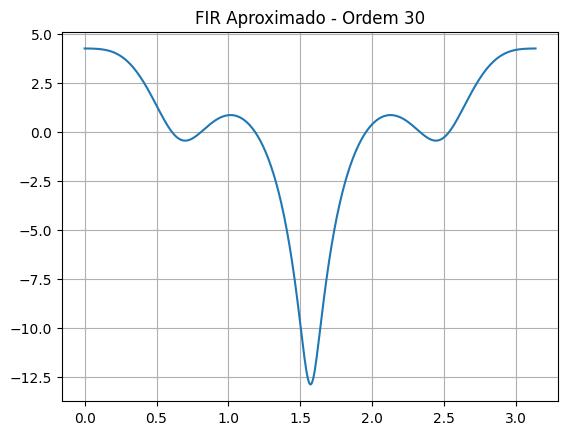

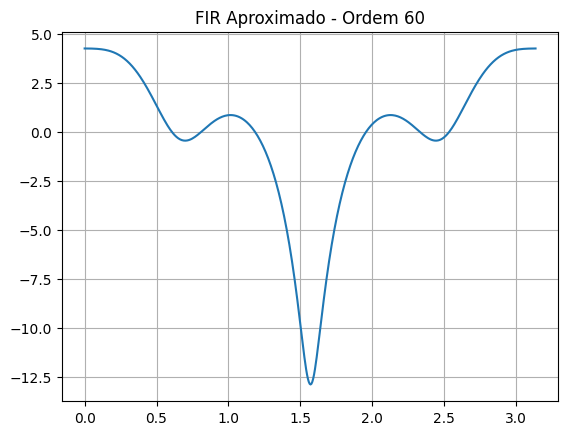

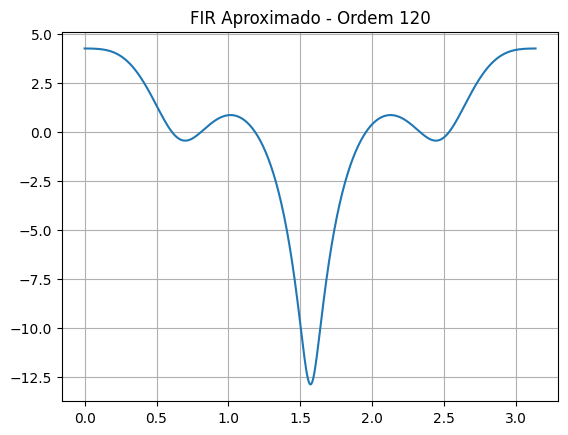

In [ ]:
# Questão 7
ordens = [30, 60, 120]

for ordem in ordens:
    imp = np.zeros(ordem)
    imp[0] = 1
    h_fir = signal.lfilter(b1, a1, imp) # Exemplo para o sistema da Q3

    w, h = signal.freqz(h_fir, [1])
    plt.figure()
    plt.plot(w, 20 * np.log10(abs(h) + 1e-10))
    plt.title(f'FIR Aproximado - Ordem {ordem}')
    plt.grid()
    plt.show()